In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Telecom_customer_churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.drop(["customerID"],axis=1,inplace=True)

In [6]:
df.duplicated().sum() # this will check the duplicate data for all columns

22

In [7]:
df.drop_duplicates(keep="last",inplace=True)

In [8]:
df.shape

(7021, 20)

In [9]:
df["TotalCharges"].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [10]:
df[df["TotalCharges"].isin([' ','NA','-'])==True]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [11]:
# Replacing whitespace with null vallues
df["TotalCharges"]=df["TotalCharges"].replace(" ",np.nan)

In [12]:
# Converting object datatype into float
df["TotalCharges"]=df["TotalCharges"].astype(float)

In [13]:
df["TotalCharges"].fillna(df["TotalCharges"].mean(),inplace=True)

C:\Users\Lakshya\AppData\Local\Temp\ipykernel_21044\3497282575.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].mean(),inplace=True)


C:\Users\Lakshya\AppData\Local\Temp\ipykernel_21044\2543898854.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["TotalCharges"],color="b")


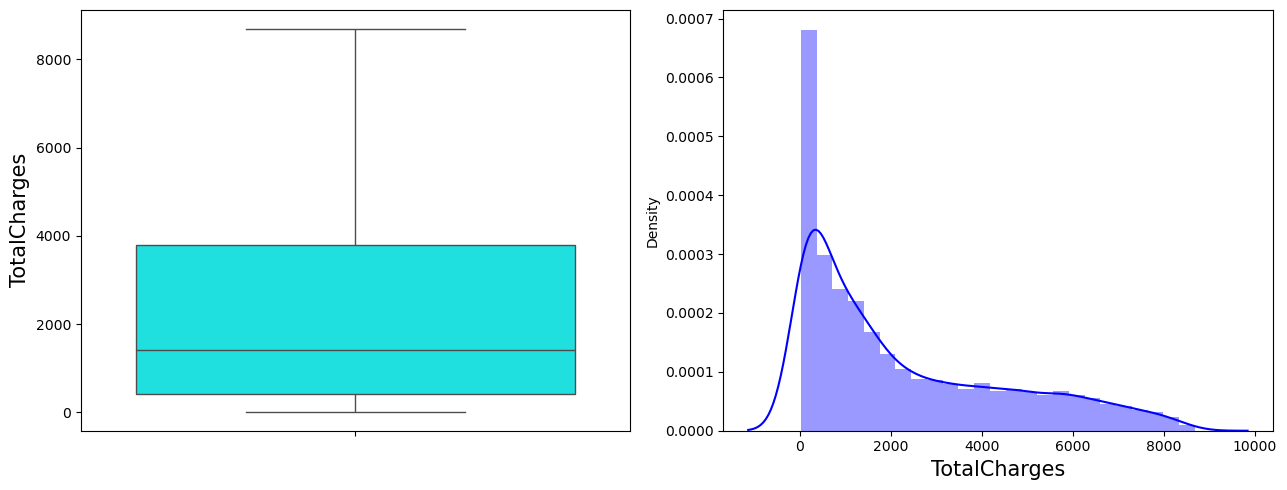

In [14]:
plt.figure(figsize=(13,5))
plt.subplot(1,2,1)
sns.boxplot(y="TotalCharges", data=df,color="cyan")
plt.ylabel("TotalCharges",fontsize=15)
plt.subplot(1,2,2)
sns.distplot(df["TotalCharges"],color="b")
plt.xlabel("TotalCharges",fontsize=15)
plt.tight_layout()
plt.show()


In [15]:
Numerical=df.select_dtypes(exclude="object")
Categorical=df.select_dtypes(include="object")

In [16]:
Numerical.shape

(7021, 4)

In [17]:
Categorical.shape

(7021, 16)

In [18]:
for i in Categorical:
    print(df[i].value_counts())
    print("="*100)

gender
Male      3541
Female    3480
Name: count, dtype: int64
Partner
No     3619
Yes    3402
Name: count, dtype: int64
Dependents
No     4911
Yes    2110
Name: count, dtype: int64
PhoneService
Yes    6339
No      682
Name: count, dtype: int64
MultipleLines
No                  3368
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3090
DSL            2419
No             1512
Name: count, dtype: int64
OnlineSecurity
No                     3490
Yes                    2019
No internet service    1512
Name: count, dtype: int64
OnlineBackup
No                     3080
Yes                    2429
No internet service    1512
Name: count, dtype: int64
DeviceProtection
No                     3087
Yes                    2422
No internet service    1512
Name: count, dtype: int64
TechSupport
No                     3465
Yes                    2044
No internet service    1512
Name: count, dtype: int64
StreamingTV
No                     2802
Y

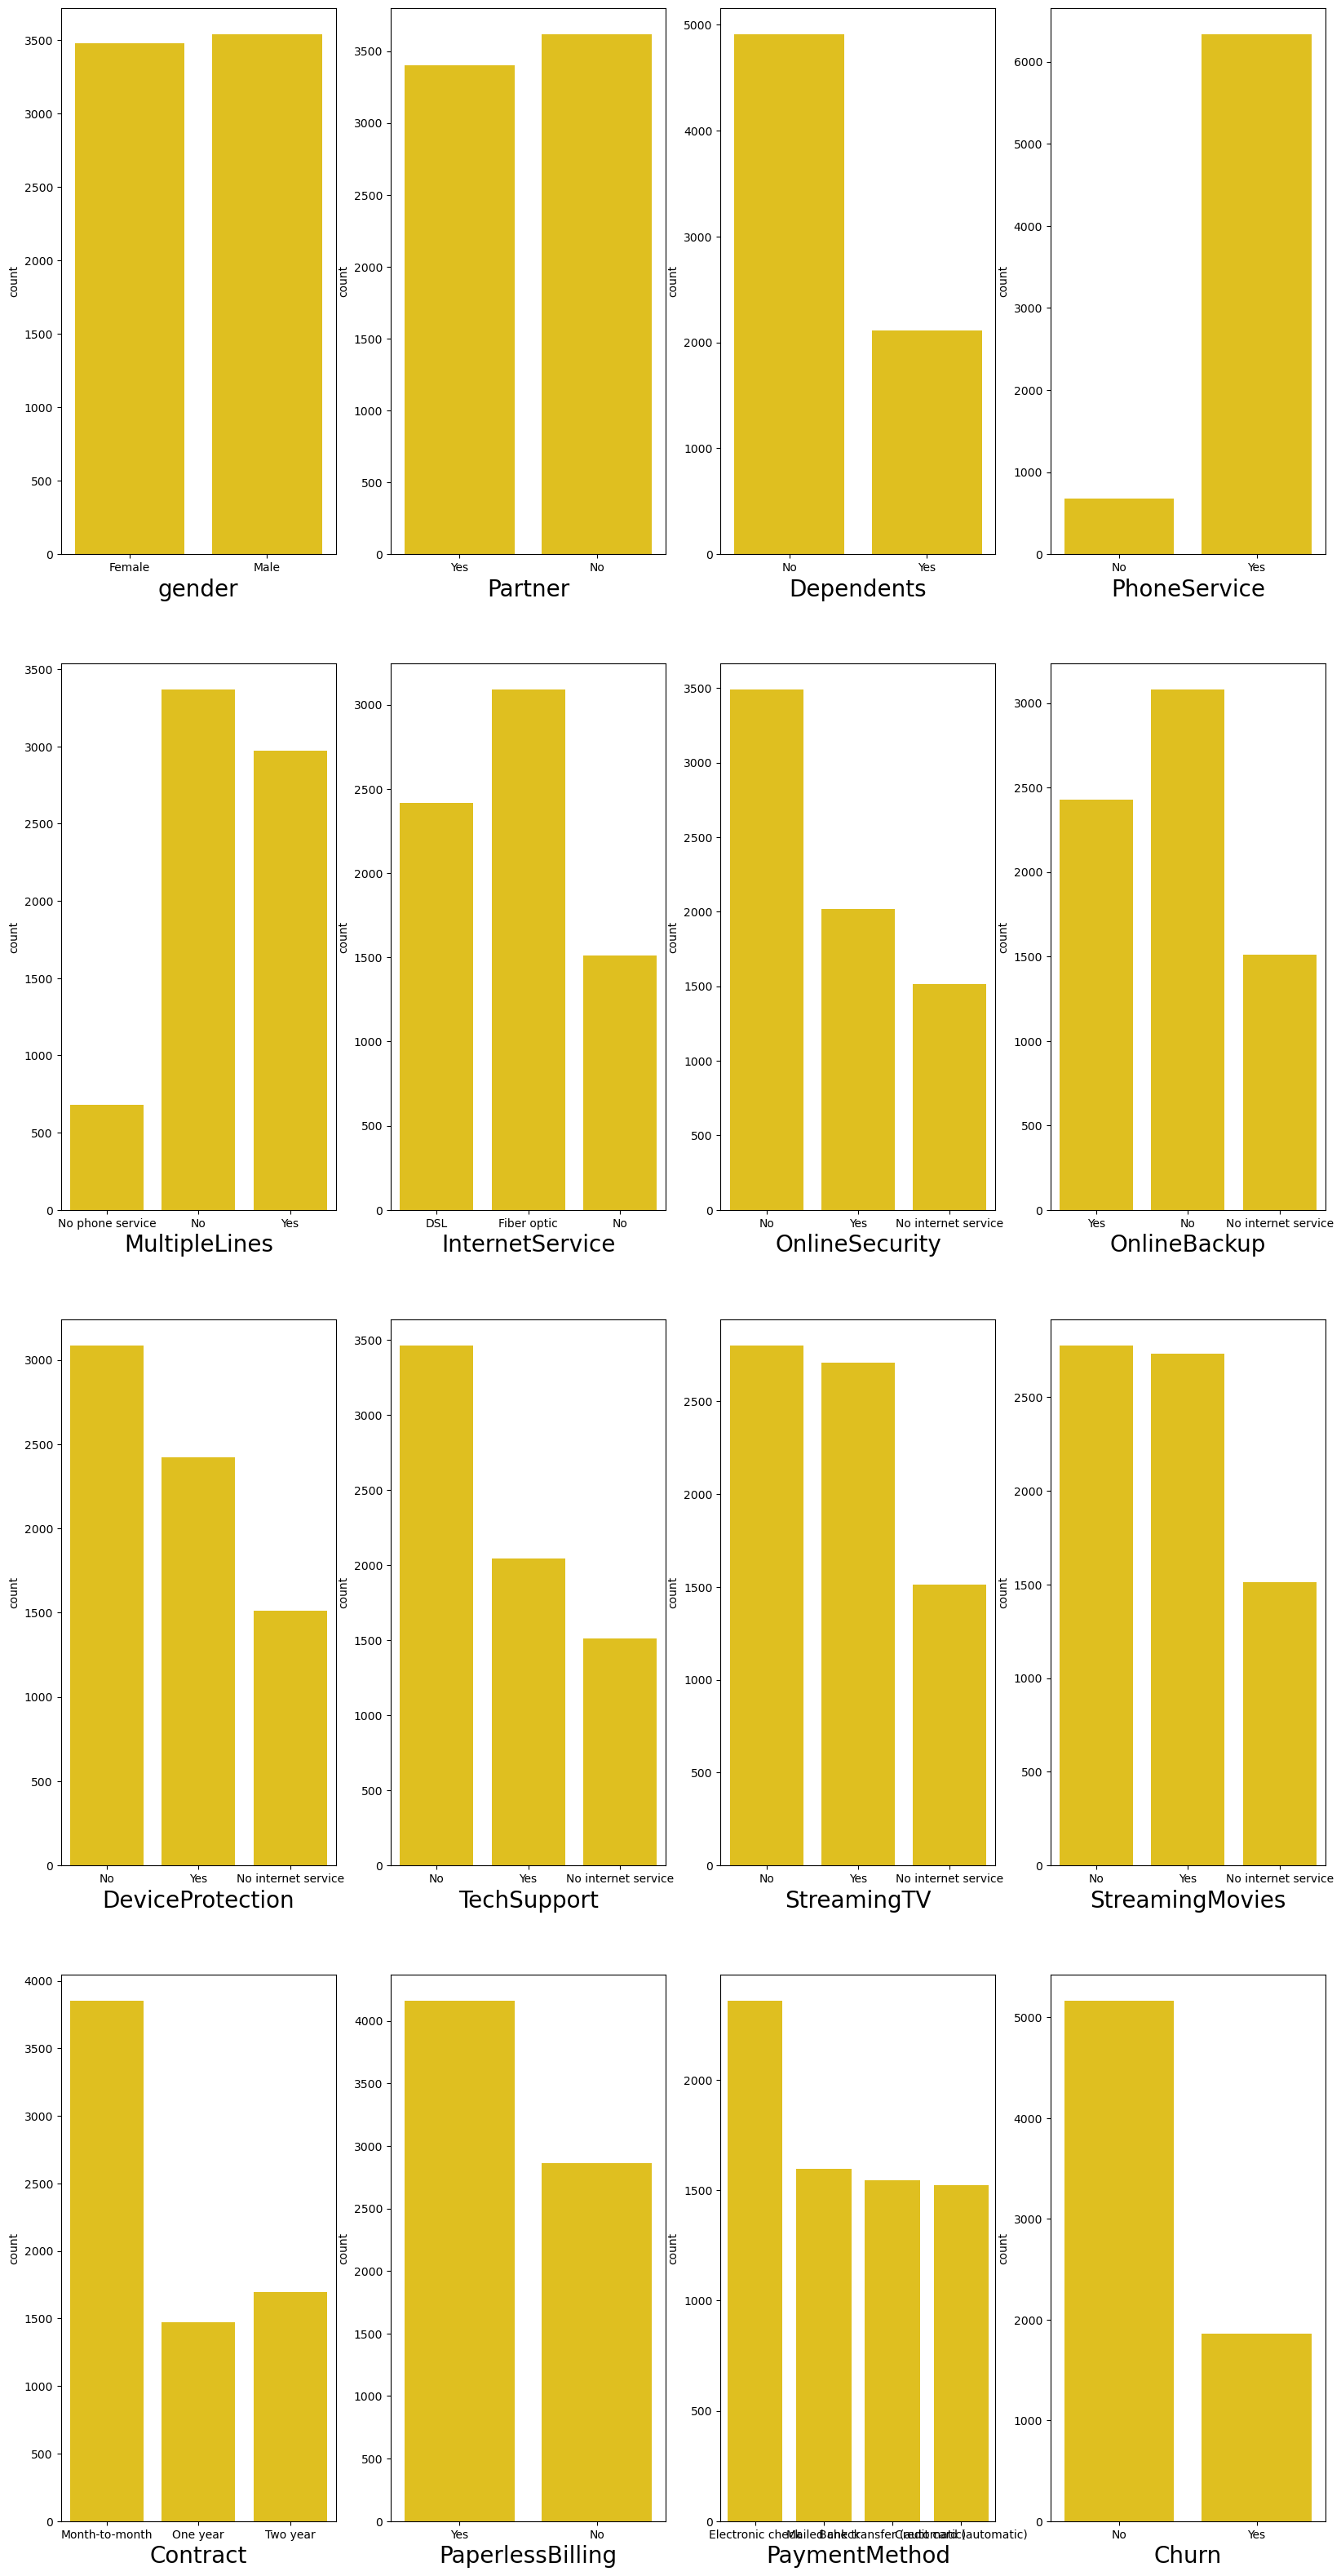

In [19]:
sns.set_palette("hsv")
plt.figure(figsize=(20,40), facecolor="white")  # plot run 16 times in one code by using loop 
plotnumber=1
for i in Categorical:
    if plotnumber <=16:
        ax=plt.subplot(4,4,plotnumber)
        sns.countplot(x=df[i])
        plt.xlabel(i,fontsize=20)
    plotnumber+=1
plt.show()

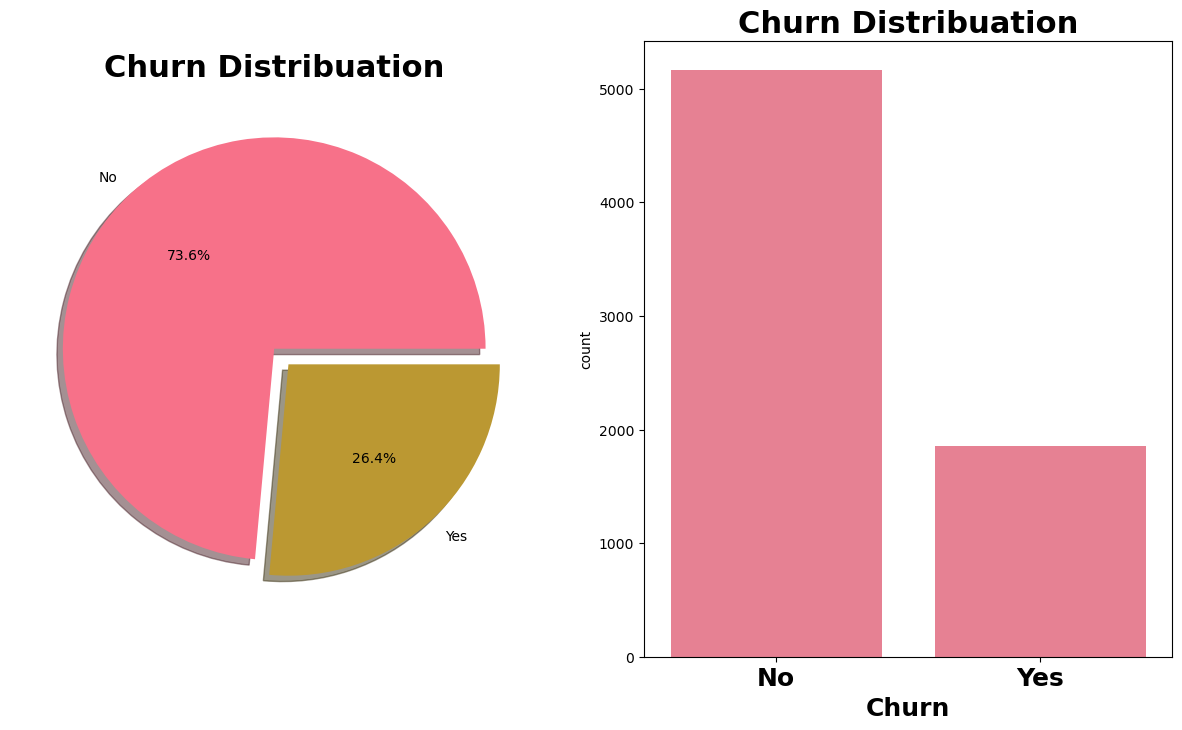

In [20]:
sns.set_palette("husl")
f,ax=plt.subplots(1,2,figsize=(15,8))
df["Churn"].value_counts().plot.pie(explode=[0,0.1],autopct='%3.1f%%',
                                    ax=ax[0],shadow=True)
ax[0].set_title("Churn Distribuation", fontsize=22,fontweight="bold")
ax[0].set_ylabel('')
sns.countplot(x="Churn",data=df,ax=ax[1])
ax[1].set_title("Churn Distribuation", fontsize=22,fontweight="bold")
ax[1].set_xlabel("Churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=18,fontweight="bold")
plt.show()

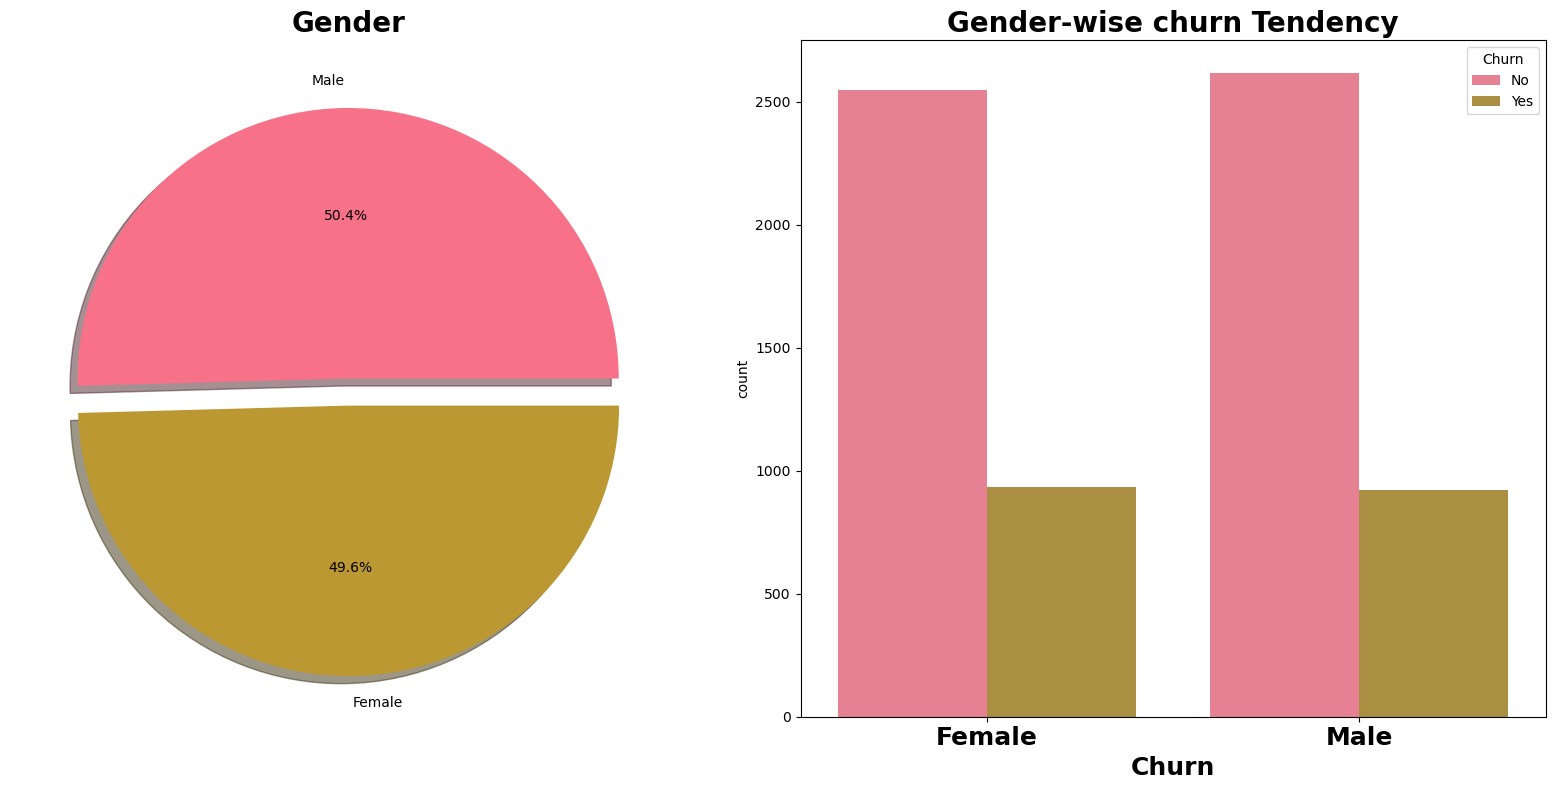

In [21]:
sns.set_palette("husl")
f,ax=plt.subplots(1,2,figsize=(16,8))                                                 
df["gender"].value_counts().plot.pie(explode=[0,0.1],autopct='%3.1f%%',
                                    ax=ax[0],shadow=True)
ax[0].set_title("Gender", fontsize=20,fontweight="bold")                             # tight_layout is margain
ax[0].set_ylabel('')
sns.countplot(x="gender",hue="Churn",data=df,ax=ax[1])
ax[1].set_title("Gender-wise churn Tendency", fontsize=20,fontweight="bold")
ax[1].set_xlabel("Churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

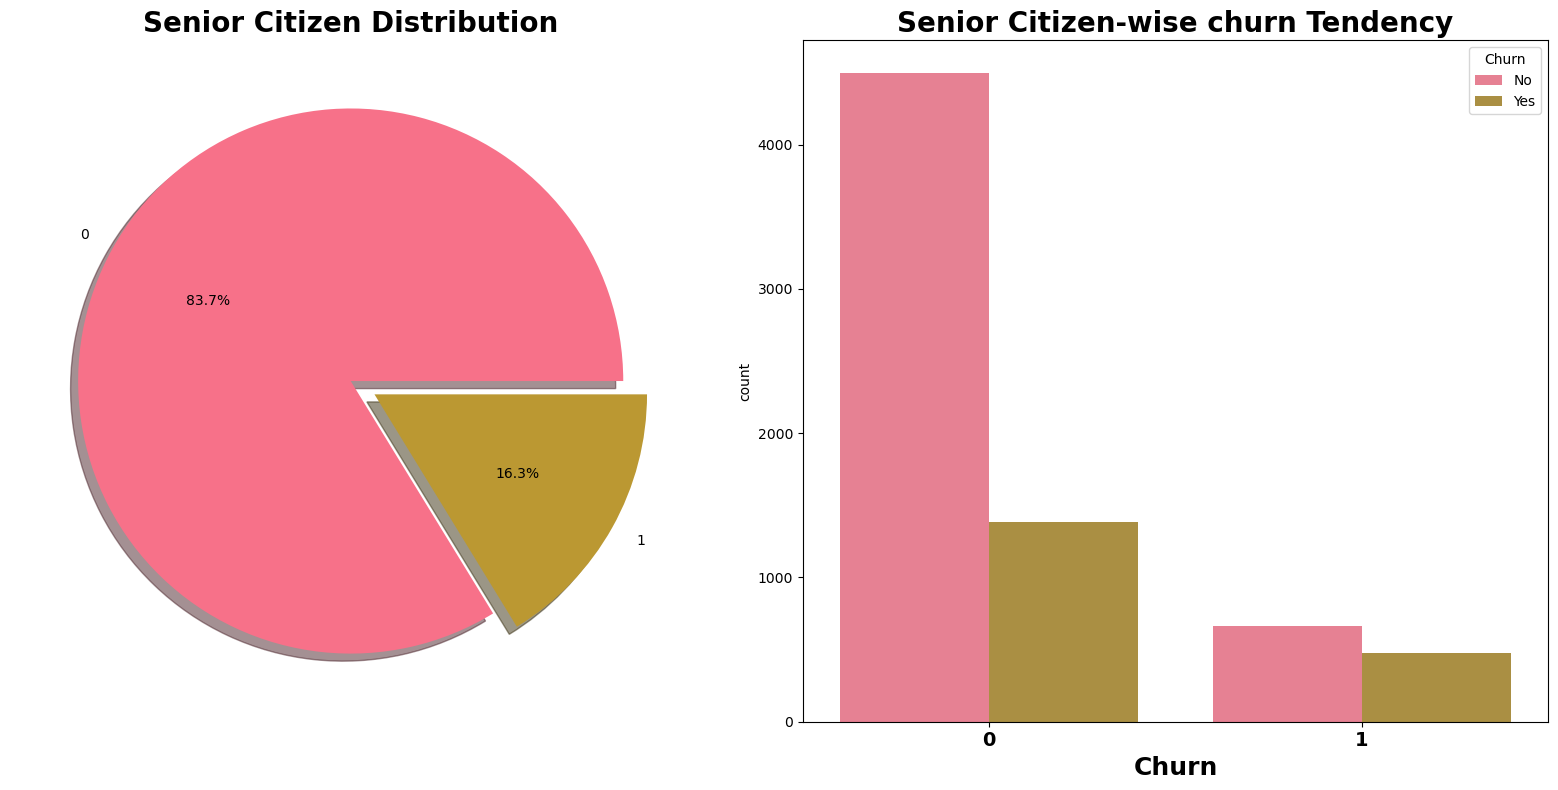

In [22]:
sns.set_palette("husl")
f,ax=plt.subplots(1,2,figsize=(16,8))                                                 
df["SeniorCitizen"].value_counts().plot.pie(explode=[0,0.1],autopct='%3.1f%%',
                                    ax=ax[0],shadow=True)
ax[0].set_title("Senior Citizen Distribution", fontsize=20,fontweight="bold")                             # tight_layout is margain
ax[0].set_ylabel('')
sns.countplot(x="SeniorCitizen",hue="Churn",data=df,ax=ax[1])
ax[1].set_title("Senior Citizen-wise churn Tendency", fontsize=20,fontweight="bold")
ax[1].set_xlabel("Churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show()

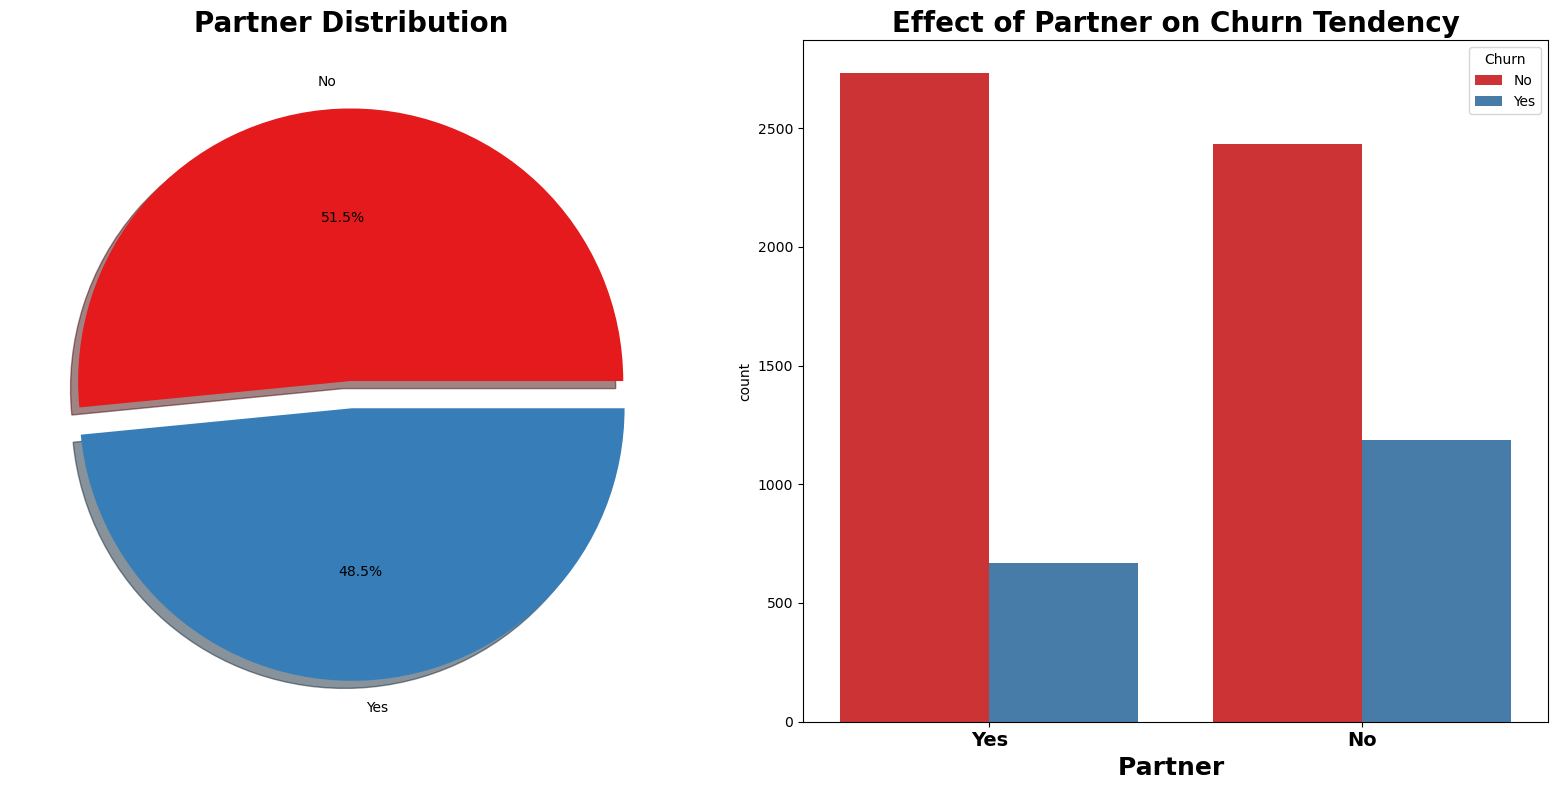

In [23]:
sns.set_palette('Set1')
f,ax=plt.subplots(1,2,figsize=(16,8))
df['Partner'].value_counts().plot.pie(explode=[0,0.1],autopct='%2.1f%%',
                                          ax=ax[0],shadow=True)
ax[0].set_title('Partner Distribution', fontsize=20,fontweight ='bold')
ax[0].set_ylabel('')
sns.countplot(x='Partner',hue="Churn",data=df,ax=ax[1])
ax[1].set_title('Effect of Partner on Churn Tendency',fontsize=20,fontweight ='bold')
ax[1].set_xlabel("Partner ",fontsize=18,fontweight ='bold')
plt.xticks(fontsize=14,fontweight ='bold')
plt.tight_layout()
plt.show()

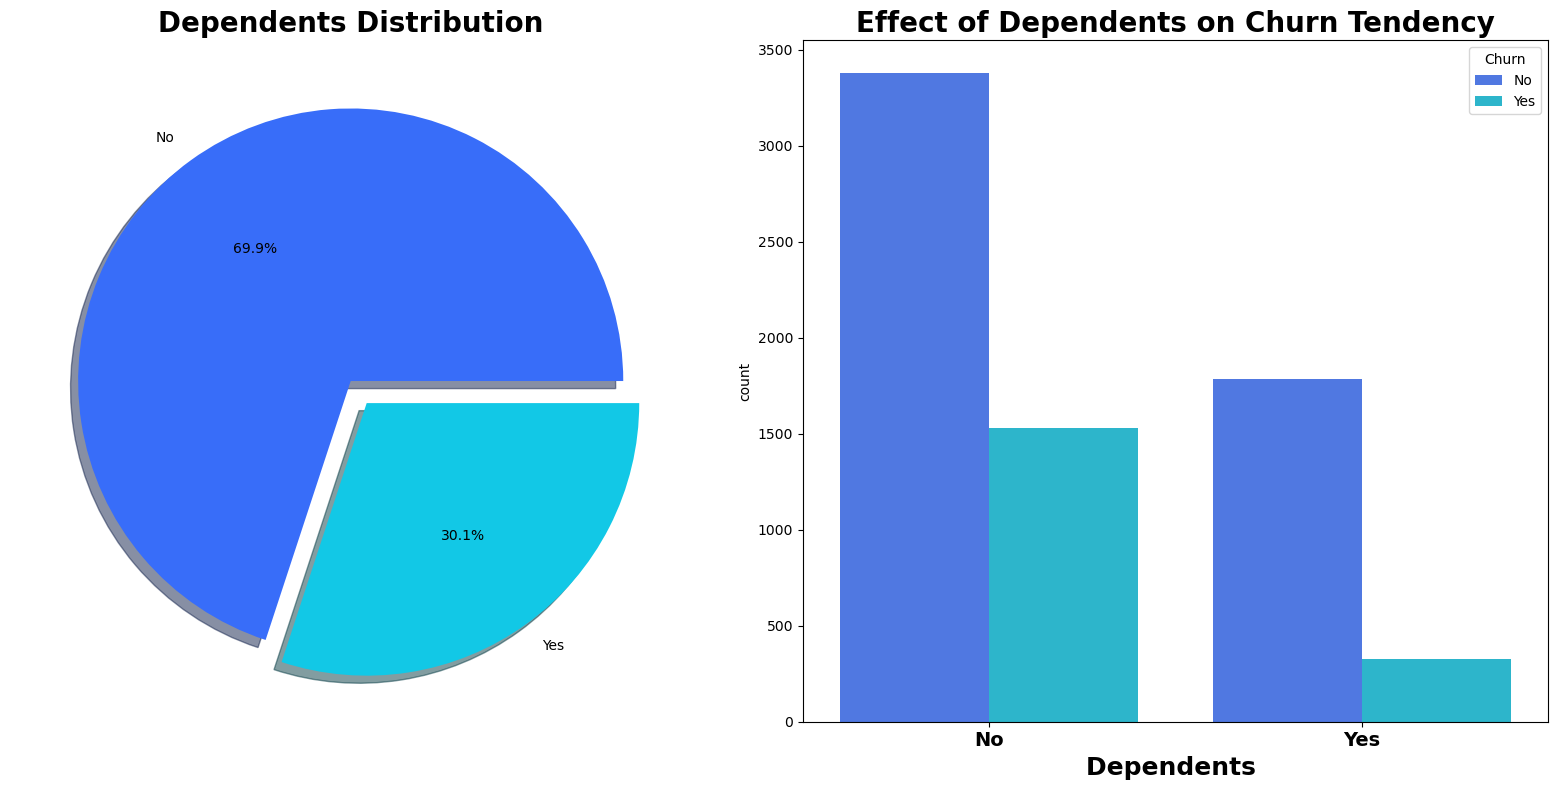

In [24]:
sns.set_palette('rainbow')
f,ax=plt.subplots(1,2,figsize=(16,8))
df['Dependents'].value_counts().plot.pie(explode=[0,0.1],autopct='%2.1f%%',
                                          ax=ax[0],shadow=True)
ax[0].set_title('Dependents Distribution', fontsize=20,fontweight ='bold')
ax[0].set_ylabel('')
sns.countplot(x='Dependents',hue="Churn",data=df,ax=ax[1])
ax[1].set_title('Effect of Dependents on Churn Tendency',fontsize=20,fontweight ='bold')
ax[1].set_xlabel("Dependents ",fontsize=18,fontweight ='bold')
plt.xticks(fontsize=14,fontweight ='bold')
plt.tight_layout()
plt.show()

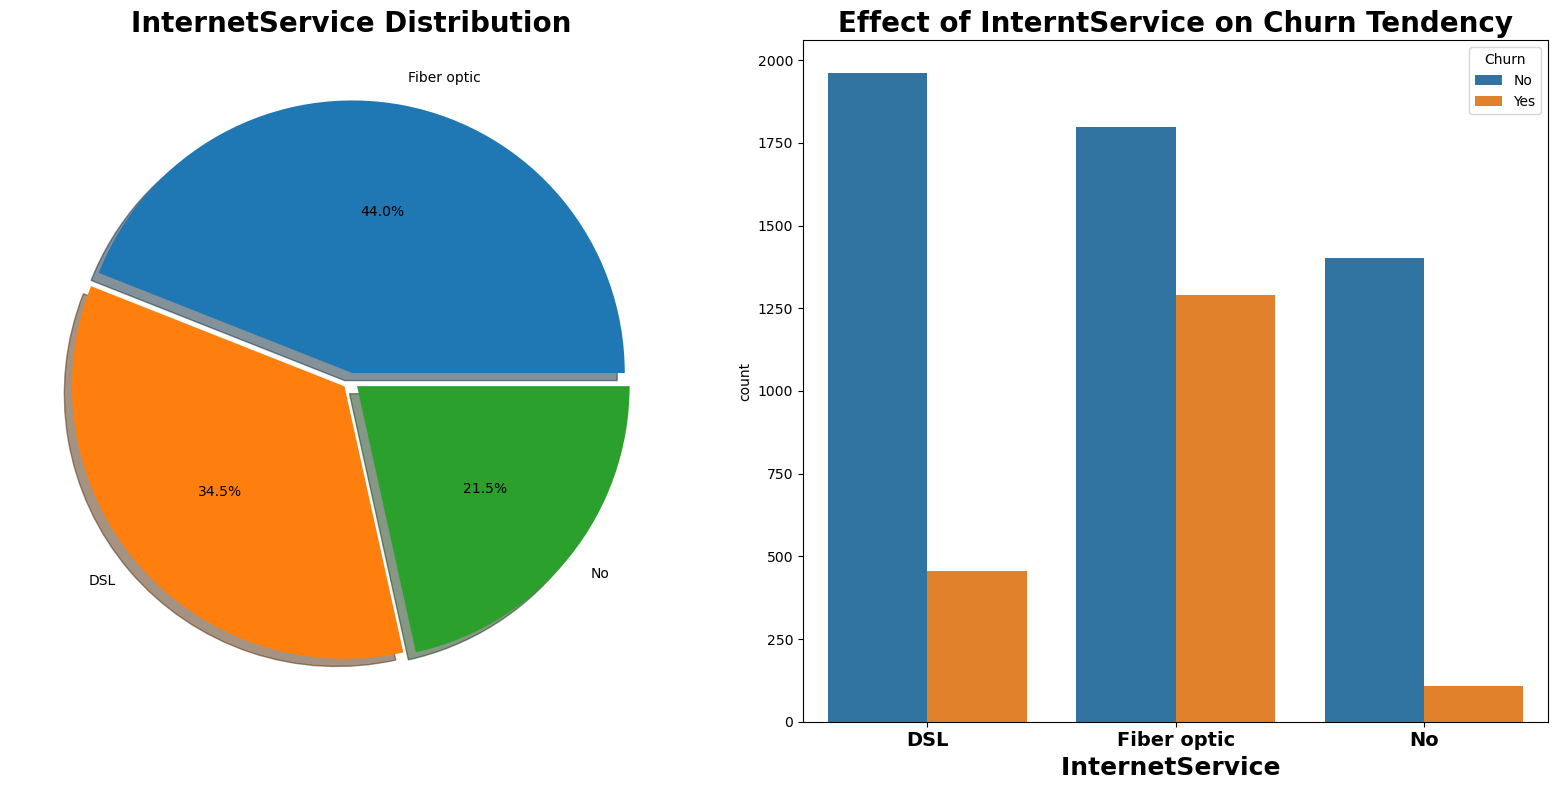

In [25]:
sns.set_palette('tab10')
f,ax=plt.subplots(1,2,figsize=(16,8))
df['InternetService'].value_counts().plot.pie(explode=[0.03,0.03,0.03],autopct='%2.1f%%',
                                          ax=ax[0],shadow=True)
ax[0].set_title('InternetService Distribution', fontsize=20,fontweight ='bold')
ax[0].set_ylabel('')
sns.countplot(x='InternetService',hue="Churn",data=df,ax=ax[1])
ax[1].set_title('Effect of InterntService on Churn Tendency',fontsize=20,fontweight ='bold')
ax[1].set_xlabel("InternetService ",fontsize=18,fontweight ='bold')
plt.xticks(fontsize=14,fontweight ='bold')
plt.tight_layout()
plt.show()

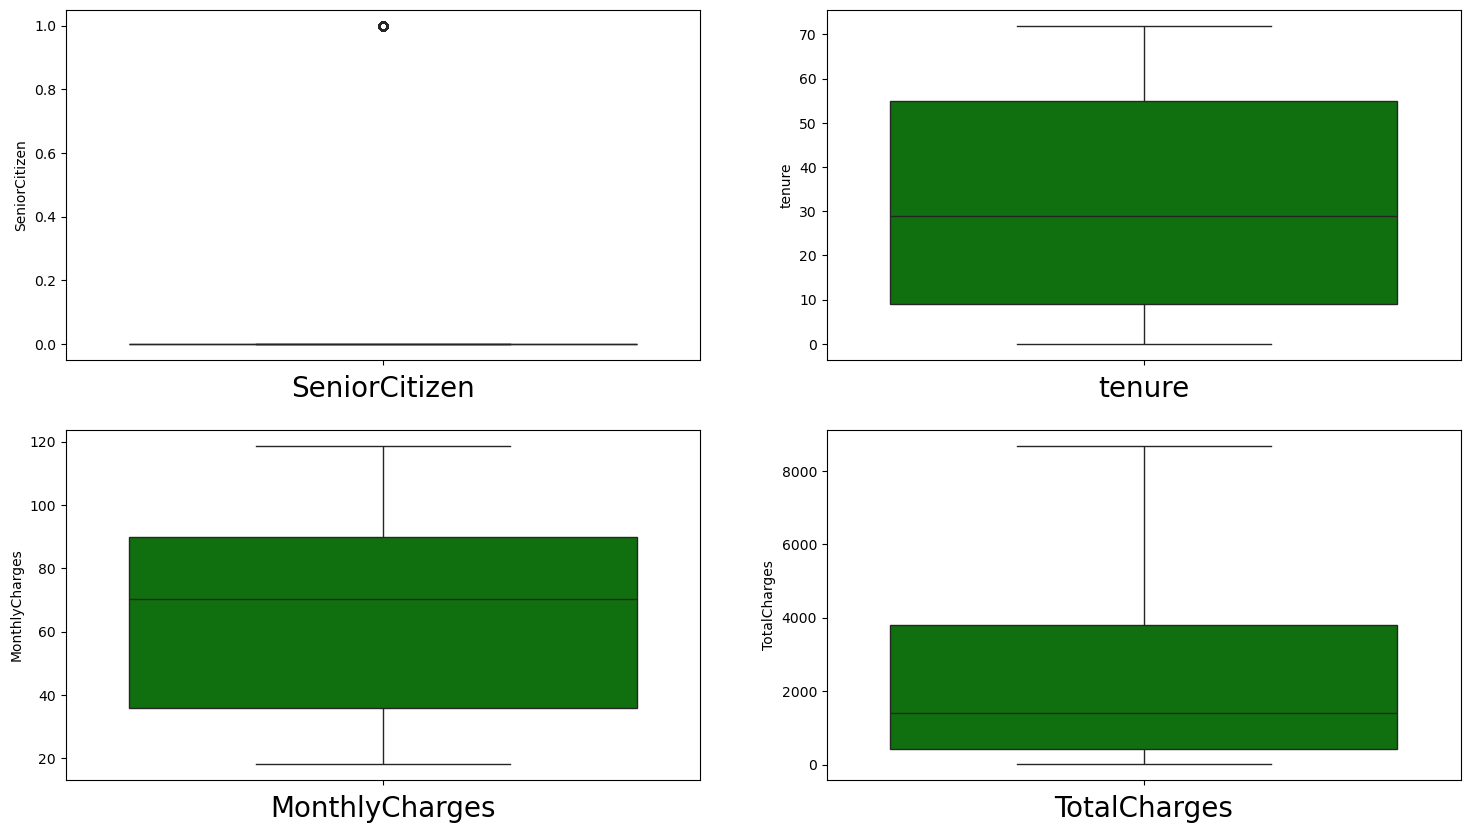

In [26]:
plt.figure(figsize=(18,10),facecolor="white")
plotnumber=1

for column in Numerical:
    if plotnumber<=4:
        ax=plt.subplot(2,2,plotnumber)
        sns.boxplot(df[column],color="g")
        plt.xlabel(column,fontsize=20)
        plotnumber+=1
plt.show()

C:\Users\Lakshya\AppData\Local\Temp\ipykernel_21044\3630821859.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
C:\Users\Lakshya\AppData\Local\Temp\ipykernel_21044\3630821859.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
C:\Users\Lakshya\AppData\Local\Temp\ipykernel_21

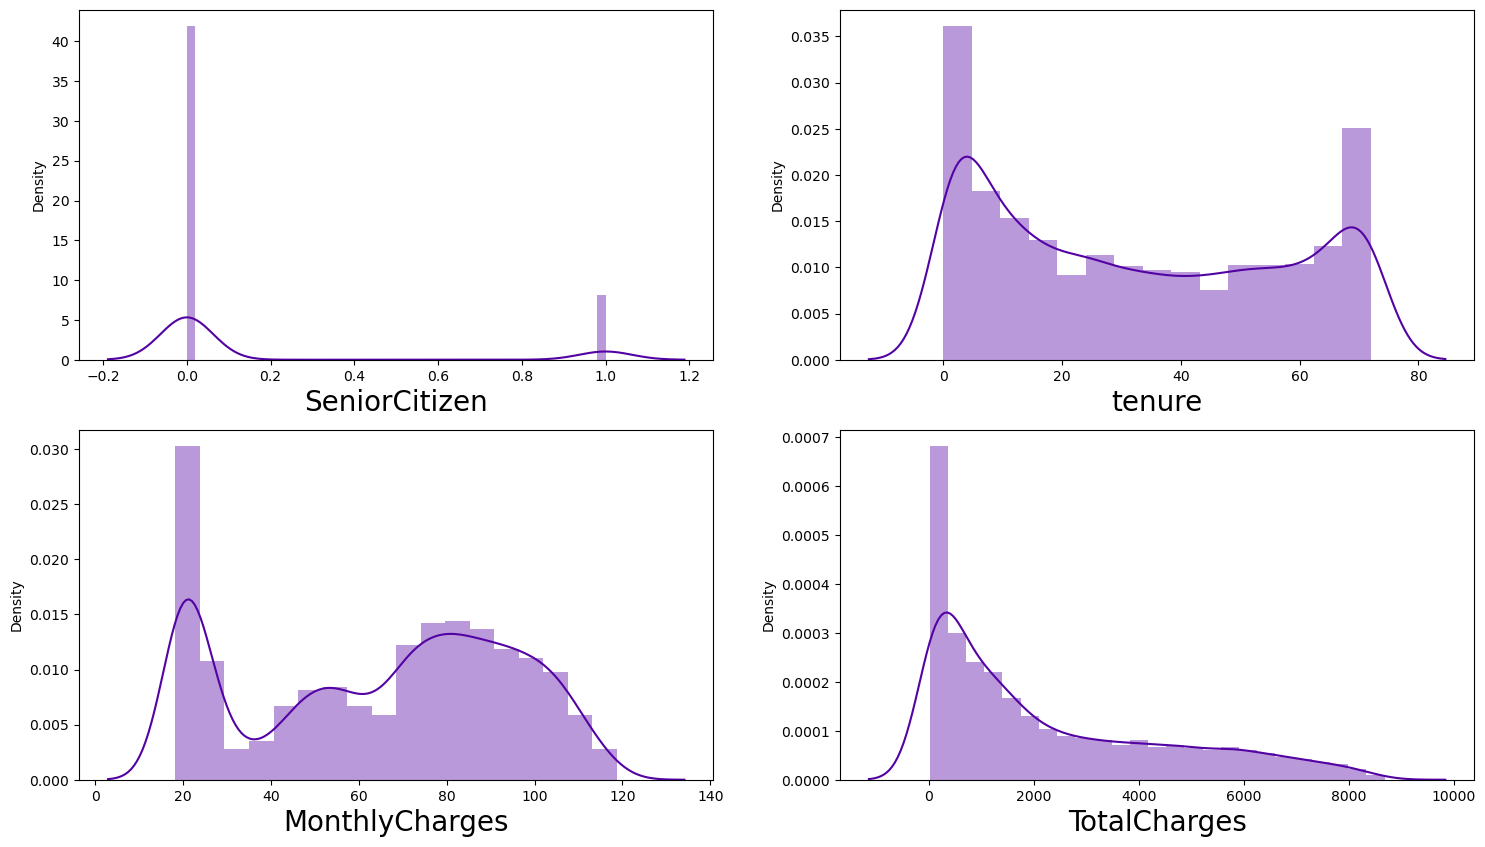

In [27]:
plt.figure(figsize=(18,10),facecolor="white")
sns.set_palette("plasma")
plotnumber=1

for col in Numerical:
    if plotnumber<=4:
        ax=plt.subplot(2,2,plotnumber)
        sns.distplot(df[col])
        plt.xlabel(col,fontsize=20)
        plotnumber+=1
plt.show()